In [1]:
# Exploraotry Data Analysis
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import ast
 
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("pastel")
 
# Paths
DATA_DIR = Path("../data/dataset")
PROMPT_PATH = DATA_DIR / "prompts_dataset.json"
 
# Load dataset
with open(PROMPT_PATH, "r") as f:
    raw_data = json.load(f)
 
df_prompts = pd.DataFrame(raw_data)

In [2]:
# Handle list column (prompt_tags)
if df_prompts["prompt_tags"].dtype == "object":
    df_prompts["prompt_tags"] = df_prompts["prompt_tags"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
 
print(f"Dataset loaded: {len(df_prompts)} prompts")
df_prompts.head()

Dataset loaded: 100 prompts


,query_id,prompt,ambiguity_tier,ground_truth,prompt_tags
0,1,How many full-time and part-time employees did...,1,local,"[amazon, headcount, 10K_fact, specific_date, l..."
1,2,What are the two main customer group strategie...,1,local,"[adobe, strategy, 10K_fact, customer_segments,..."
2,3,What four reportable operating segments does A...,1,local,"[amex, business_segments, 10K_fact, organizati..."
3,4,What was Alphabet's aggregate market value of ...,1,local,"[alphabet, market_cap, 10K_fact, specific_date..."
4,5,What three business segments does Amazon organ...,1,local,"[amazon, business_segments, 10K_fact, organiza..."


In [3]:
# Schema Validation
required_cols = {"query_id", "prompt", "ambiguity_tier", "ground_truth", "prompt_tags"}
missing = required_cols - set(df_prompts.columns)
assert len(missing) == 0, f"Missing columns: {missing}"
 
assert df_prompts["ambiguity_tier"].isin([1, 2, 3]).all(), "Invalid ambiguity_tier values"
assert df_prompts["ground_truth"].isin(["local", "web", "uncertain"]).all(), "Invalid ground_truth values"
print("Schema validation passed")

Schema validation passed


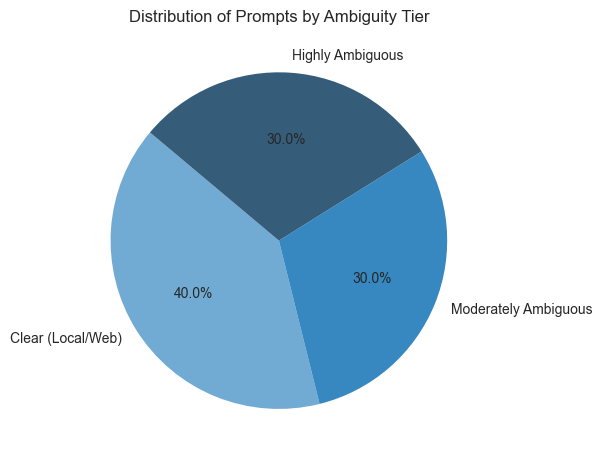

In [4]:
# Distribution of Ambiguity Tiers
tier_counts = df_prompts["ambiguity_tier"].value_counts().sort_index()
tier_labels = {1: "Clear (Local/Web)", 2: "Moderately Ambiguous", 3: "Highly Ambiguous"}
 
plt.figure(figsize=(6, 6))
plt.pie(
    tier_counts.values,
    labels=tier_counts.index.map(tier_labels),
    autopct="%1.1f%%",
    colors=sns.color_palette("Blues_d", len(tier_counts)),
    startangle=140
)
plt.title("Distribution of Prompts by Ambiguity Tier")
plt.tight_layout()
plt.show()

/var/folders/zh/yms1gjd96710vz87_cq258l40000gn/T/ipykernel_37069/809272777.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_prompts, x="ambiguity_tier", y="word_count", palette="Blues")


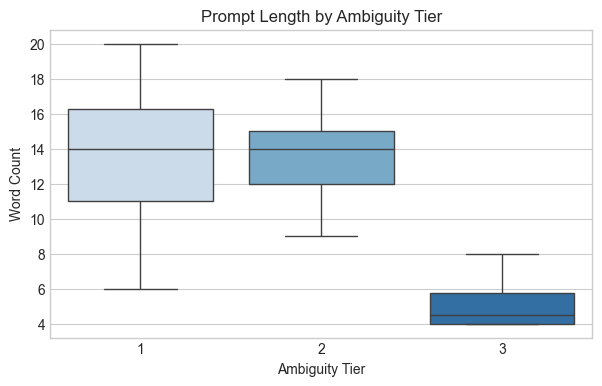

In [5]:
df_prompts["word_count"] = df_prompts["prompt"].apply(lambda x: len(x.split()))

plt.figure(figsize=(7, 4))
sns.boxplot(data=df_prompts, x="ambiguity_tier", y="word_count", palette="Blues")
plt.title("Prompt Length by Ambiguity Tier")
plt.xlabel("Ambiguity Tier")
plt.ylabel("Word Count")
plt.show()

Ground Truth vs Ambiguity Tier:
                    Clear (Local/Web)  Moderately Ambiguous  Highly Ambiguous
ground_truth                                                                 
Local (Historical)                 20                    19                13
Web (Real-time)                    20                    11                17


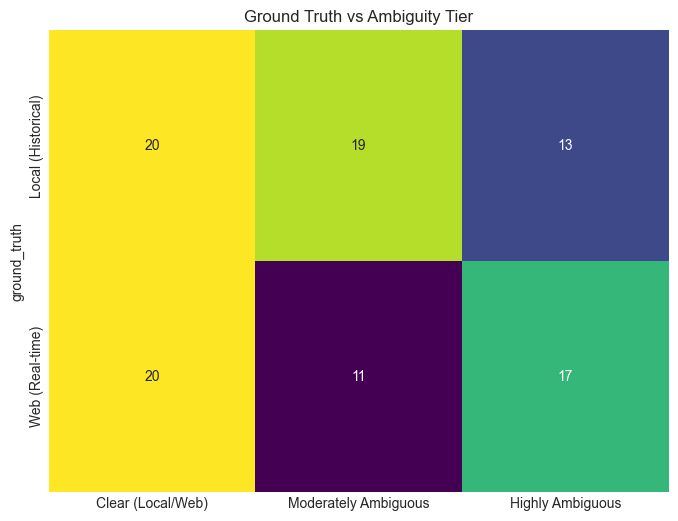

In [6]:
# Ground Truth vs Ambiguity Tier Analysis
ct = pd.crosstab(df_prompts["ground_truth"], df_prompts["ambiguity_tier"])
ct.index = ct.index.map({"local": "Local (Historical)", "web": "Web (Real-time)", "uncertain": "Ambiguous"})
ct.columns = [tier_labels[i] for i in ct.columns]
print("Ground Truth vs Ambiguity Tier:")
print(ct)
plt.figure(figsize=(8, 6))
sns.heatmap(ct, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.title("Ground Truth vs Ambiguity Tier")
plt.savefig("../data/results/gt_vs_tiers.png", dpi=150)

/var/folders/zh/yms1gjd96710vz87_cq258l40000gn/T/ipykernel_37069/1154447846.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tags_df, x="tag", y="count", palette="magma")


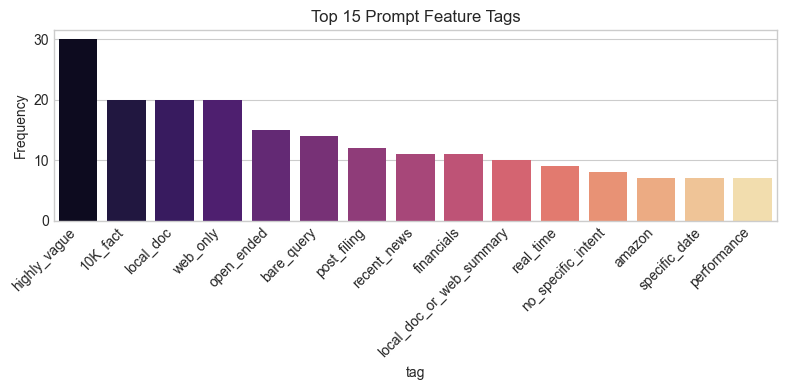

In [7]:
# Prompt Tag Frequency Analysis
from collections import Counter
all_tags = [tag for sublist in df_prompts["prompt_tags"] for tag in sublist]
tag_counts = Counter(all_tags).most_common(15)
 
tags_df = pd.DataFrame(tag_counts, columns=["tag", "count"])
plt.figure(figsize=(8, 4))
sns.barplot(data=tags_df, x="tag", y="count", palette="magma")
plt.xticks(rotation=45, ha="right")
plt.title("Top 15 Prompt Feature Tags")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

ground_truth          local  web
No Temporal Keyword      28   32
Has Temporal Keyword     24   16

Temporal keyword → 'web' precision: 40.0%


Text(0.5, 1.0, 'Temporal Keyword Presence vs Ground Truth')

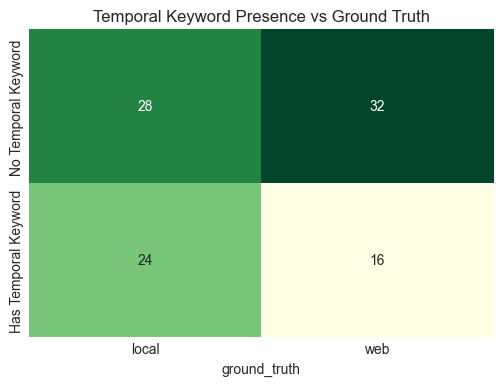

In [8]:
# Temporal Keyword Analysis
temporal_keywords = ["today", "current", "latest", "now", "recent", "2025", "FY2025", "this year", "this quarter"]

def has_temporal(prompt):
    return any(kw.lower() in prompt.lower() for kw in temporal_keywords)

df_prompts["has_temporal_keyword"] = df_prompts["prompt"].apply(has_temporal)

ct = pd.crosstab(df_prompts["has_temporal_keyword"], df_prompts["ground_truth"])
ct.index = ["No Temporal Keyword", "Has Temporal Keyword"]
print(ct)

precision = ct.loc["Has Temporal Keyword", "web"] / ct.loc["Has Temporal Keyword"].sum()
print(f"\nTemporal keyword → 'web' precision: {precision:.1%}")
plt.figure(figsize=(6, 4))
sns.heatmap(ct, annot=True, fmt="d", cmap="YlGn", cbar=False)
plt.title("Temporal Keyword Presence vs Ground Truth")

/var/folders/zh/yms1gjd96710vz87_cq258l40000gn/T/ipykernel_37069/3800872028.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=local_top, x="count", y="tag", ax=axes[0], palette="Blues_d")
/var/folders/zh/yms1gjd96710vz87_cq258l40000gn/T/ipykernel_37069/3800872028.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=web_top,   x="count", y="tag", ax=axes[1], palette="Greens_d")


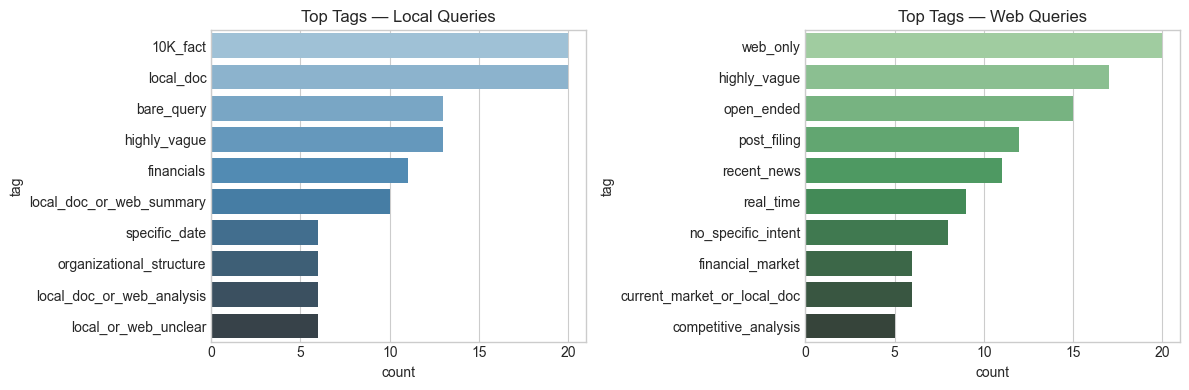

In [9]:
# Tag Distribution by Ground Truth
local_tags = [t for _, row in df_prompts[df_prompts["ground_truth"]=="local"].iterrows() for t in row["prompt_tags"]]
web_tags   = [t for _, row in df_prompts[df_prompts["ground_truth"]=="web"].iterrows()   for t in row["prompt_tags"]]

local_top = pd.Series(Counter(local_tags)).nlargest(10).reset_index()
web_top   = pd.Series(Counter(web_tags)).nlargest(10).reset_index()
local_top.columns = ["tag", "count"]; web_top.columns = ["tag", "count"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=local_top, x="count", y="tag", ax=axes[0], palette="Blues_d")
axes[0].set_title("Top Tags — Local Queries")
sns.barplot(data=web_top,   x="count", y="tag", ax=axes[1], palette="Greens_d")
axes[1].set_title("Top Tags — Web Queries")
plt.tight_layout() 
plt.show()

In [10]:
# Sample Prompts per Tier
for tier in [1, 2, 3]:
    sample = df_prompts[df_prompts["ambiguity_tier"] == tier].sample(2, random_state=42)
    print(f"\nTier {tier} ({tier_labels[tier]}):")
    for _, row in sample.iterrows():
        print(f"ID: {row['query_id']} | GT: {row['ground_truth']}")
        print(f"\"{row['prompt']}\"")
        print(f"Tags: {row['prompt_tags']}")
        print("-" * 60)


Tier 1 (Clear (Local/Web)):
ID: 40 | GT: local
"What was Pinterest's global monthly active user count as reported in its FY2025 annual filing?"
Tags: ['pinterest', 'monthly_active_users', '10K_fact', 'platform_metrics', 'local_doc']
------------------------------------------------------------
ID: 37 | GT: local
"What were IBM's total revenues for fiscal year 2025 as reported in its annual filing?"
Tags: ['ibm', 'total_revenue', '10K_fact', 'financials', 'local_doc']
------------------------------------------------------------

Tier 2 (Moderately Ambiguous):
ID: 78 | GT: local
"How does HP Inc. split its revenue between the personal systems and printing segments?"
Tags: ['hp', 'segment_revenue', 'personal_systems', 'local_doc_or_web_summary', 'printing']
------------------------------------------------------------
ID: 66 | GT: web
"How does Visa's global payment network compare to Mastercard's in terms of transaction volume and market share?"
Tags: ['visa', 'competitive_analysis', 'mas